In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Ventas TeachSales.csv",  sep=';')
df.head()

,ID_Pedido,Fecha,Producto,Categoria,Region,Monto_Venta
0,1001,1/3/2025,Laptop Gamer X,Computadoras,Centro,1800
1,1002,2/3/2025,Smartwatch S,Accesorios,Norte,250
2,1003,3/3/2025,TV 4K Pro,Televisores,Sur,950
3,1004,4/3/2025,Smartphone Z,Smartphones,Norte,700
4,1005,5/3/2025,Auriculares C,Accesorios,Centro,80


In [3]:
# Convertir la columna Fecha a formato datetime
# Usamos dayfirst=True porque tus fechas vienen como D/M/YYYY
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)

# Ordenar por fecha (esto es CRUCIAL para el cálculo acumulado)
df = df.sort_values('Fecha')


In [4]:
# 1. Agrupar por Fecha y Categoría para sumar ventas del mismo día
df_diario = df.groupby(['Fecha', 'Categoria'])['Monto_Venta'].sum().reset_index()

# 2. Calcular la suma acumulada (cumsum) separada por cada Categoría
df_diario['Monto_Acumulado'] = df_diario.groupby('Categoria')['Monto_Venta'].cumsum()

# Ver el resultado
df_diario.head(10)


,Fecha,Categoria,Monto_Venta,Monto_Acumulado
0,2025-03-01,Computadoras,1800,1800
1,2025-03-02,Accesorios,250,250
2,2025-03-03,Televisores,950,950
3,2025-03-04,Smartphones,700,700
4,2025-03-05,Accesorios,80,330
5,2025-03-06,Accesorios,120,450
6,2025-03-07,Computadoras,1500,3300
7,2025-03-08,Smartphones,650,1350
8,2025-03-09,Televisores,600,1550
9,2025-03-10,Computadoras,1300,4600


In [5]:
# Calcular el promedio de monto por categoría
promedios = df.groupby('Categoria')['Monto_Venta'].mean().round(2)

# Ver los promedios para saber qué valores estamos graficando
print("Promedios por categoría:")
print(promedios)


Promedios por categoría:
Categoria
Accesorios        89.17
Computadoras    1470.00
Smartphones      625.00
Televisores     1190.00
Name: Monto_Venta, dtype: float64


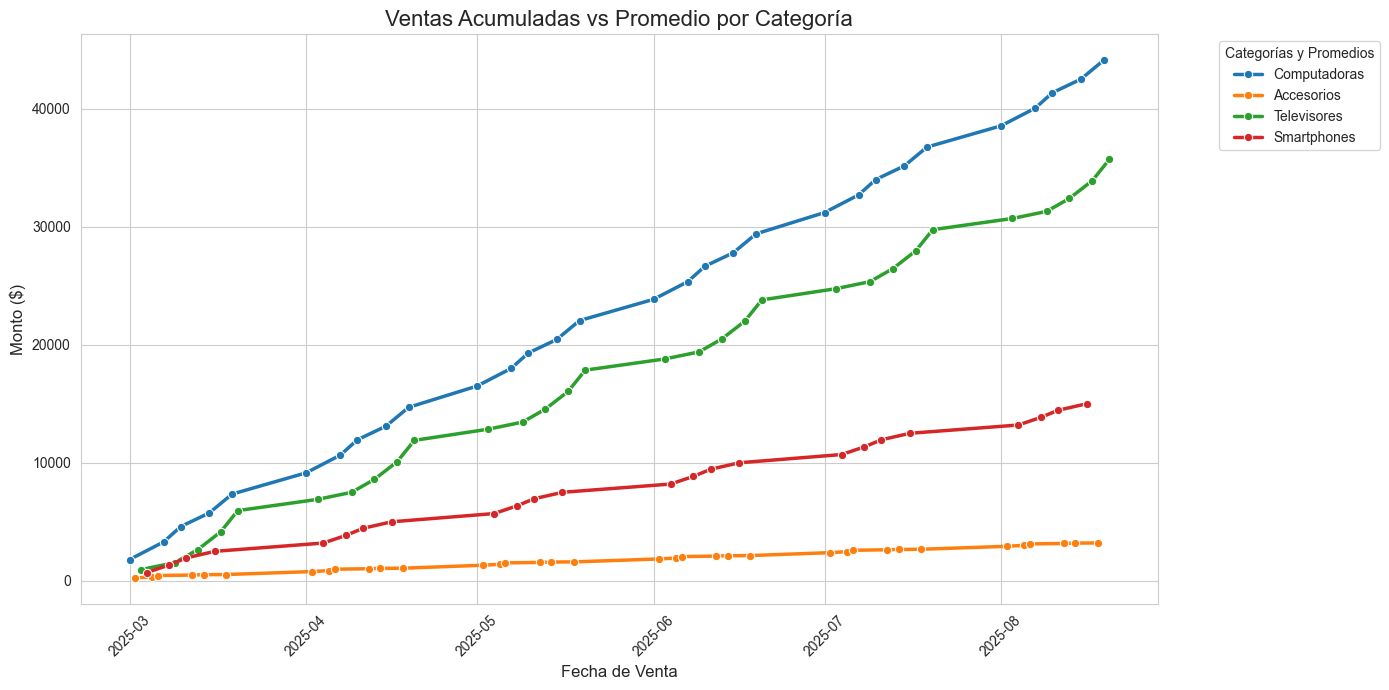

In [6]:
# Configurar el estilo del gráfico (puedes reutilizar plt.figure y sns.lineplot anteriores)
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Crear el gráfico de líneas acumuladas (igual que el paso anterior)
grafico = sns.lineplot(data=df_diario, x='Fecha', y='Monto_Acumulado', hue='Categoria', marker='o', linewidth=2.5)

# OBTENER COLORES: Necesitamos saber qué color asignó Seaborn a cada categoría
# Usaremos los colores de la paleta actual para que coincidan las líneas
colores = sns.color_palette(n_colors=len(promedios))
categorias_ordenadas = sorted(df['Categoria'].unique()) # Las categorías que graficó Seaborn

# Personalizar etiquetas y diseño
plt.title('Ventas Acumuladas vs Promedio por Categoría', fontsize=16)
plt.xlabel('Fecha de Venta', fontsize=12)
plt.ylabel('Monto ($)', fontsize=12)
plt.xticks(rotation=45)

# Ajustar leyenda para que no tape el gráfico
plt.legend(title='Categorías y Promedios', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


# Ventas acumuladas por región

In [7]:
# Sumar el monto de venta total por cada región
ventas_por_region = df.groupby('Region')['Monto_Venta'].sum()

# Ver los totales antes de graficar
print("Ventas totales por Región:")
print(ventas_por_region)


Ventas totales por Región:
Region
Centro    27750
Norte     43200
Sur       27060
Name: Monto_Venta, dtype: int64


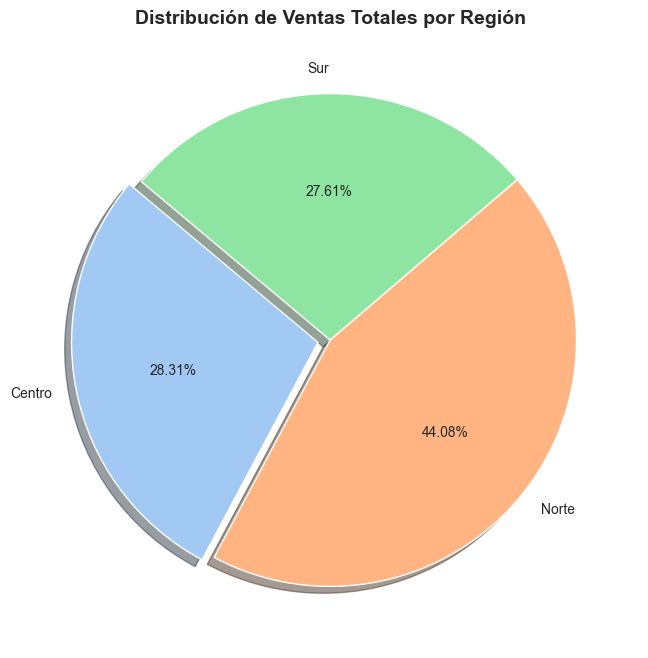

In [8]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 8))

# Definir colores elegantes
colores = sns.color_palette('pastel')[0:3]

# Crear el gráfico circular
plt.pie(ventas_por_region, 
        labels = ventas_por_region.index, 
        autopct = '%1.2f%%',           # Muestra el porcentaje con 1 decimal
        startangle = 140,              # Gira el gráfico para mejor visualización
        colors = colores,              # Usar nuestra paleta de colores
        explode = (0.05, 0, 0),        # "Saca" un poquito la primera rebanada para resaltar
        shadow = True)                 # Añade una sombra sutil

# Título del gráfico
plt.title('Distribución de Ventas Totales por Región', fontsize=14, fontweight='bold')

# Mostrar el gráfico
plt.show()


# Ventas por categoría

In [9]:
# Sumar el total de ventas acumuladas (final) por cada categoría
ventas_totales_cat = df.groupby('Categoria')['Monto_Venta'].sum().sort_values(ascending=False).reset_index()

# Ver los totales finales por categoría
print("Ventas totales acumuladas por categoría:")
print(ventas_totales_cat)


Ventas totales acumuladas por categoría:
      Categoria  Monto_Venta
0  Computadoras        44100
1   Televisores        35700
2   Smartphones        15000
3    Accesorios         3210


C:\Users\G_Laptop\AppData\Local\Temp\ipykernel_13128\1837406620.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_barras = sns.barplot(data=ventas_totales_cat,


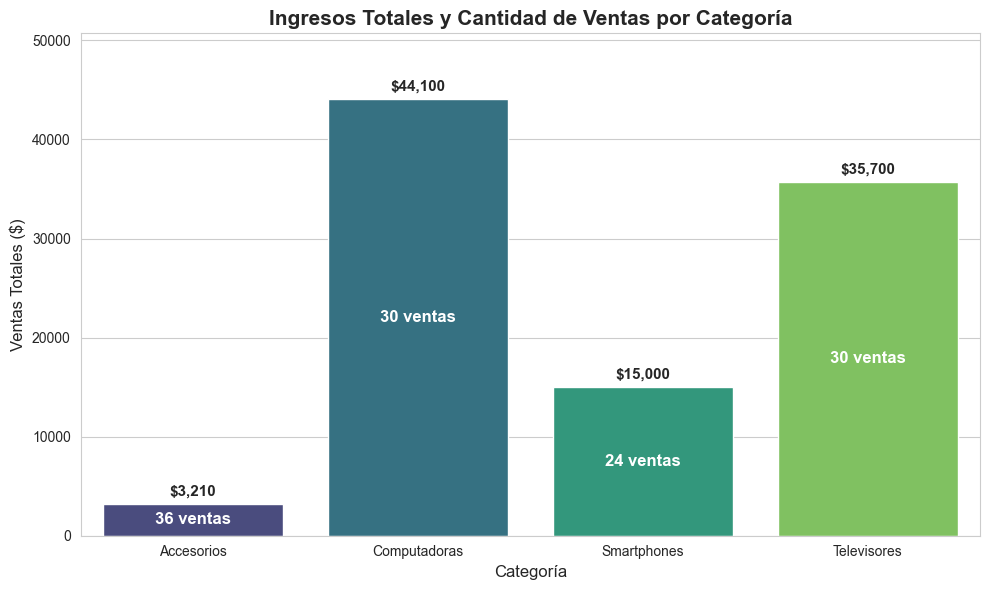

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos (calculando monto total y conteo a la vez)
ventas_totales_cat = df.groupby('Categoria').agg(
    Monto_Venta=('Monto_Venta', 'sum'),
    Cantidad_Ventas=('Monto_Venta', 'count')
).reset_index()

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Crear el gráfico de barras
grafico_barras = sns.barplot(data=ventas_totales_cat, 
                             x='Categoria',           
                             y='Monto_Venta',          
                             palette='viridis')       

# --- Añadir los valores ---

# Usamos enumerate para saber en qué barra estamos y sacar el dato de 'Cantidad_Ventas'
for i, p in enumerate(grafico_barras.patches):
    # Valor en el Eje Y (Monto total) - Se mantiene ARRIBA de la barra
    grafico_barras.annotate(f'${p.get_height():,.0f}', 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha = 'center', va = 'center', 
                            xytext = (0, 9), 
                            textcoords = 'offset points',
                            fontsize=11, fontweight='bold')
    
    # Valor del Conteo (Cantidad de ventas) - Se muestra DENTRO de la barra
    # Lo colocamos en la mitad de la altura (p.get_height() / 2)
    cantidad = ventas_totales_cat.iloc[i]['Cantidad_Ventas']
    grafico_barras.annotate(f'{cantidad} ventas', 
                            (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                            ha = 'center', va = 'center', 
                            color='white', fontsize=12, fontweight='bold')

# Etiquetas y personalización
plt.title('Ingresos Totales y Cantidad de Ventas por Categoría', fontsize=15, fontweight='bold')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)
plt.ylim(0, ventas_totales_cat['Monto_Venta'].max() * 1.15) 

plt.tight_layout()
plt.show()


# Producto Estrella

In [14]:
import plotly.express as px

# Definimos tu paleta de 4 colores con alto contraste
mis_colores = ['#E63946', '#1D3557', '#2A9D8F', '#F4A261']

fig = px.scatter(df, 
                 x='Fecha', 
                 y='Monto_Venta', 
                 color='Categoria', 
                 hover_name='Producto', 
                 title='Ventas: Monto vs Fecha por Categoría',
                 labels={'Monto_Venta': 'Monto Total ($)', 'Fecha': 'Fecha de Venta'},
                 template='plotly_white', # Fondo blanco
                 color_discrete_sequence=mis_colores) # Aplicamos tus 4 colores

# Ajuste para resaltar más los puntos
fig.update_traces(marker=dict(size=14, opacity=0.9, line=dict(width=1.5, color='white')))

fig.show()
